In [7]:
import logging
import earthaccess
import numpy as np
import rioxarray as rxa
import geopandas as gpd
import xarray as xr
import re
import pandas as pd
import py3dep
import s3fs
import matplotlib.pyplot as plt
from seaborn import set_theme
set_theme()
from shapely.geometry import box

# Setup logger
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("snow_comparison")

# Authenticate with Earthdata
auth = earthaccess.login()
if not auth.authenticated:
    auth.login(strategy="interactive", persist=True)

# Notebook Overview
This notebook compares modeled UCLA/WUS snow products and AORC meteorological fields against high-resolution QSI Lidar and SNOTEL observations.

Primary steps: 
- Load QSI Lidar granules and extract bounding boxes for study sites.
- Subset AORC and UCLA modeled datasets to the lidar footprints and target dates.
- Search and extract WUS_UCLA_SR gridded outputs (SD_POST and SWE_POST), build timeseries, and compute spatial averages over each footprint.
- Collect SNOTEL station timeseries for the same date windows and plot modeled vs observed snow depth and SWE.

Notes: network calls (Earthdata/CMR) may be slow; consider running individual cells selectively or using cached granule lists.

# Assess AORC and UCLA SWE modeled data in RMNP and Salt Lake City 

1. Download Lidar data from NSIDC 
2. Get bounding boxes 
3. Download modeled data sets in bounding box 


In [8]:
# Define target granule names (without extension to avoid naming mismatch)
target_granules = [
    "SNEX20_QSI_SD_0.5M_USCOCP_20210319_20210319",
    "SNEX20_QSI_SD_0.5M_USUTLC_20210318_20210318"
]

logger.info("Searching for SNEX20_QSI_SD granules...")
broad_grans = earthaccess.search_data(
    short_name='SNEX20_QSI_SD',
    cloud_hosted=True,
    temporal=('2021-03-18', '2021-03-19'),
)

# Strict filtering by exact filename match
lidar_grans = [
    g for g in broad_grans 
    if any(target in (g.path if hasattr(g, 'path') else str(g)) for target in target_granules)
]

logger.info(f"Filtered down to {len(lidar_grans)} exact granules.")

# Open the fileset using earthaccess
lidar_fileset = earthaccess.open(lidar_grans)

INFO:snow_comparison:Searching for SNEX20_QSI_SD granules...
INFO:earthaccess.api:Granules found: 3
INFO:snow_comparison:Filtered down to 2 exact granules.
INFO:earthaccess.store:Opening 2 granules, approx size: 0.44 GB
QUEUEING TASKS | : 100%|██████████| 2/2 [00:00<00:00, 610.17it/s]
PROCESSING TASKS | : 100%|██████████| 2/2 [00:01<00:00,  1.13it/s]
COLLECTING RESULTS | : 100%|██████████| 2/2 [00:00<00:00, 62601.55it/s]


In [9]:
# Dictionary to store datasets and bounding geometries
sites_data = {}

for g in lidar_grans:
    # 1. Use the native method to extract the file download URLs safely
    file_url = g.data_links()[0] 
    
    site_id = "CO_20210319" if "USCOCP" in file_url else "UT_20210318"
    date_str = "2021-03-19" if "USCOCP" in file_url else "2021-03-18"
    
    logger.info(f"Extracting metadata bounds for {site_id}...")
    
    # 2. Extract the spatial boundaries by digging into the actual ['umm'] metadata dictionary
    points = g['umm']['SpatialExtent']['HorizontalSpatialDomain']['Geometry']['GPolygons'][0]['Boundary']['Points']
    
    lons = [p['Longitude'] for p in points]
    lats = [p['Latitude'] for p in points]
    
    # Calculate the bounding box extent
    minx, maxx = min(lons), max(lons)
    miny, maxy = min(lats), max(lats)
    
    # Create the shapely box directly in EPSG:4326
    polygon_4326 = box(minx, miny, maxx, maxy)
    
    # Store the granule metadata and object for later use
    sites_data[site_id] = {
        'granule': g,  # Saved to open lazily during plotting
        'polygon': polygon_4326,
        'date': date_str,
        'bbox_coords': (minx, miny, maxx, maxy)
    }

print("Extracted bounding boxes from metadata successfully.")

INFO:snow_comparison:Extracting metadata bounds for UT_20210318...
INFO:snow_comparison:Extracting metadata bounds for CO_20210319...


Extracted bounding boxes from metadata successfully.


In [10]:
# Define AORC base configuration
AORC_S3_BASE_URL = "noaa-nws-aorc-v1-1-1km" # Adjust bucket name if your endpoint differs
years = [2021]

s3_out = s3fs.S3FileSystem(anon=True)
fileset_aorc = [
    s3fs.S3Map(root=f"s3://{AORC_S3_BASE_URL}/{yr}.zarr", s3=s3_out, check=False)
    for yr in years
]

try:
    logger.info("Opening AORC zarr store...")
    ds_aorc_full = xr.open_mfdataset(fileset_aorc, engine='zarr')
    ds_aorc_full = ds_aorc_full.rename({'latitude': 'y', 'longitude': 'x'})
except Exception as exc:
    logger.error(f"Failed to open AORC zarr store: {exc}")
    raise

# Subset AORC data for each site and its specific target date
for site_id, info in sites_data.items():
    minx, miny, maxx, maxy = info['bbox_coords']
    target_date = info['date']
    
    # AORC latitudes are often sorted descending. We handle slice sorting safely here:
    y_slice = slice(maxy, miny) if ds_aorc_full.y[0] > ds_aorc_full.y[-1] else slice(miny, maxy)
    x_slice = slice(maxx, minx) if ds_aorc_full.x[0] > ds_aorc_full.x[-1] else slice(minx, maxx)
    
    # Slice spatially and temporally (selecting the specific day)
    ds_aorc_subset = ds_aorc_full.sel(x=x_slice, y=y_slice)
    ds_aorc_day = ds_aorc_subset.sel(time=target_date).mean(dim='time') # Daily average if hourly
    
    # Store back to our tracking dictionary
    sites_data[site_id]['aorc'] = ds_aorc_day
    logger.info(f"AORC data subsetted for {site_id}")

INFO:snow_comparison:Opening AORC zarr store...
INFO:snow_comparison:AORC data subsetted for UT_20210318
INFO:snow_comparison:AORC data subsetted for CO_20210319


In [ ]:
# WUS (UCLA SR) extraction
# For each site we: 
# 1. build a polygon footprint from the lidar granule,
# 2. search CMR/Earthdata for WUS_UCLA_SR granules overlapping that footprint and the target temporal window,
# 3. open SD_POST files, standardize coordinates and time axis, concatenate by time,
# 4. clip the multi-day stack to the lidar footprint and target date, and store a per-site dataset for later comparison.
for site_id, info in sites_data.items():
    poly = info['polygon']
    x_coords, y_coords = poly.exterior.coords.xy
    poly_list = list(zip(x_coords, y_coords))
    
    logger.info(f"Searching WUS_UCLA_SR data for {site_id}...")
    try:
        wus_grans = earthaccess.search_data(
            short_name='WUS_UCLA_SR',
            cloud_hosted=True,
            temporal=('2021-03-18', '2021-03-19'),
            polygon=poly_list,
        )
    except Exception as exc:
        logger.error(f"earthaccess.search_data failed for WUS_UCLA_SR: {exc}")
        raise

    wus_fileset = earthaccess.open(wus_grans)
    sd_files = [f for f in wus_fileset if "SD_POST" in (f.path if hasattr(f, 'path') else str(f))]
    
    if sd_files:
        processed_ds_list = []
        
        # Process each granule inlining only the core extraction and re-indexing logic
        for f in sd_files:
            filename = f.path if hasattr(f, 'path') else str(f)
            ds = xr.open_dataset(f, chunks={})
            
            # Extract Water Year and build daily time axis
            start_year = int(re.search(r'WY(\d{4})_\d{2}', filename).group(1))
            time_coords = pd.date_range(start=f"{start_year}-10-01", periods=ds.sizes['Day'], freq='D')
            
            # Flatten spatial arrays and standardize names
            lat_vals = ds.Latitude.values.flatten()
            lon_vals = ds.Longitude.values.flatten()
            
            ds = ds.rename({'Day': 'time', 'Latitude': 'y', 'Longitude': 'x'})
            ds = ds.assign_coords(time=time_coords, y=lat_vals, x=lon_vals)
            processed_ds_list.append(ds)
        
        # Combine the cleanly indexed datasets
        ds_wus = xr.concat(processed_ds_list, dim='time').sortby('time')
        
        # Crop spatially to the Lidar bounding box
        minx, miny, maxx, maxy = info['bbox_coords']
        y_slice = slice(miny, maxy) if ds_wus.y[0] < ds_wus.y[-1] else slice(maxy, miny)
        x_slice = slice(minx, maxx) if ds_wus.x[0] < ds_wus.x[-1] else slice(maxx, minx)
        
        # Filter both spatially and temporally for the specific lidar acquisition date
        sites_data[site_id]['wus_ucla'] = ds_wus.sel(x=x_slice, y=y_slice).sel(time=info['date'], method='nearest')
        logger.info(f"WUS_UCLA_SR Snow Depth successfully processed for {site_id}")
    else:
        logger.warning(f"No matching SD_POST files found for {site_id}")

INFO:snow_comparison:Searching WUS_UCLA_SR data for UT_20210318...
INFO:earthaccess.api:Granules found: 2
INFO:earthaccess.store:Opening 2 granules, approx size: 0.22 GB
QUEUEING TASKS | : 100%|██████████| 2/2 [00:00<00:00, 2820.65it/s]
PROCESSING TASKS | : 100%|██████████| 2/2 [00:01<00:00,  1.44it/s]
COLLECTING RESULTS | : 100%|██████████| 2/2 [00:00<00:00, 27776.85it/s]
INFO:fsspec:BlockCache fetching block (sync) 0
INFO:fsspec:BlockCache fetching block (async) 1
INFO:fsspec:BlockCache fetching block (sync) 20
INFO:fsspec:BlockCache joined background fetch without waiting.
INFO:fsspec:BlockCache fetching block (async) 21
INFO:snow_comparison:WUS_UCLA_SR Snow Depth successfully processed for UT_20210318
INFO:snow_comparison:Searching WUS_UCLA_SR data for CO_20210319...
INFO:earthaccess.api:Granules found: 2
INFO:earthaccess.store:Opening 2 granules, approx size: 0.26 GB
QUEUEING TASKS | : 100%|██████████| 2/2 [00:00<00:00, 2680.92it/s]
PROCESSING TASKS | : 100%|██████████| 2/2 [00:01

INFO:fsspec:BlockCache fetching block (async) 8
INFO:fsspec:BlockCache fetching block (async) 8
INFO:fsspec:BlockCache fetching block (async) 13
INFO:fsspec:BlockCache fetching block (async) 13


In [12]:
processed_plots_data = {}

for site_id, info in sites_data.items():
    logger.info(f"Aligning Lidar and UCLA grids for {site_id}...")
    
    # 1. Fetch data arrays
    da_ucla = info['wus_ucla']
    ucla_var = 'SD_POST' if 'SD_POST' in da_ucla.data_vars else list(da_ucla.data_vars)[0]
    da_ucla_snow = da_ucla[ucla_var]
    
    # --- CRITICAL FIX: Handle Ensemble and Time Dimensions ---
    # Squeeze out or select the target date
    if 'time' in da_ucla_snow.dims:
        da_ucla_snow = da_ucla_snow.squeeze('time') if da_ucla_snow.sizes['time'] == 1 else da_ucla_snow.isel(time=0)
        
    # Find and subset the 3rd ensemble index (index 2)
    # Identifies dimensions that aren't the standard spatial 'x' or 'y' keys
    potential_ensemble_dims = [dim for dim in da_ucla_snow.dims if dim not in ['x', 'y']]
    
    for dim in potential_ensemble_dims:
        logger.info(f"Slicing 3rd ensemble member (median) from dimension: '{dim}'")
        da_ucla_snow = da_ucla_snow.isel({dim: 2})
        
    # Final safety squeeze to remove any leftover singular dimensions
    da_ucla_snow = da_ucla_snow.squeeze()
    # ---------------------------------------------------------
    
    if da_ucla_snow.rio.crs is None:
        da_ucla_snow = da_ucla_snow.rio.write_crs("EPSG:4326")
        
    if 'x' in da_ucla_snow.coords and 'y' in da_ucla_snow.coords:
        da_ucla_snow = da_ucla_snow.set_index(x='x', y='y')
        
    # Open and stream remote QSI Lidar file
    lidar_file = earthaccess.open([info['granule']])[0]
    da_lidar = rxa.open_rasterio(lidar_file, chunks={'x': 2000, 'y': 2000}).squeeze()
    
    # 2. Match resolutions and clear nodata anomalies
    da_lidar_aligned = da_lidar.rio.reproject_match(da_ucla_snow)
    da_lidar_aligned = da_lidar_aligned.where(da_lidar_aligned >= 0)
    da_ucla_snow = da_ucla_snow.where(da_ucla_snow >= 0)
    
    # 3. Calculate Model Bias (Residuals)
    snow_difference = da_ucla_snow - da_lidar_aligned
    
    # Cache everything safely into memory
    processed_plots_data[site_id] = {
        'date': info['date'],
        'lidar_aligned': da_lidar_aligned,
        'ucla_snow': da_ucla_snow,
        'difference': snow_difference,
        'lidar_vals': da_lidar_aligned.values,
        'ucla_vals': da_ucla_snow.values,
        'diff_vals': snow_difference.values
    }

print("Grid alignment completed successfully. Your arrays are strictly 2D.")

INFO:snow_comparison:Aligning Lidar and UCLA grids for UT_20210318...
INFO:snow_comparison:Slicing 3rd ensemble member (median) from dimension: 'Stats'
INFO:earthaccess.store:Opening 1 granules, approx size: 0.26 GB
QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 7516.67it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.55s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 33288.13it/s]
INFO:fsspec:BlockCache joined background fetch without waiting.
INFO:fsspec:BlockCache fetching block (sync) 7
INFO:fsspec:BlockCache fetching block (sync) 12
INFO:snow_comparison:Aligning Lidar and UCLA grids for CO_20210319...
INFO:snow_comparison:Slicing 3rd ensemble member (median) from dimension: 'Stats'
INFO:earthaccess.store:Opening 1 granules, approx size: 0.19 GB
QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 5121.25it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.48s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 38479.85it/

Grid alignment completed successfully. Your arrays are strictly 2D.


INFO:fsspec:BlockCache joined background fetch without waiting.
INFO:fsspec:BlockCache joined background fetch without waiting.
INFO:fsspec:BlockCache joined background fetch without waiting.


In [13]:
import contextily as cx
from rasterio.enums import Resampling

INFO:snow_comparison:Generating aligned reference maps for UT_20210318...
INFO:earthaccess.store:Opening 1 granules, approx size: 0.26 GB
QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 1721.80it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.23s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 15887.52it/s]
INFO:snow_comparison:Reprojecting and downsampling Lidar to 5m resolution in EPSG:4326...


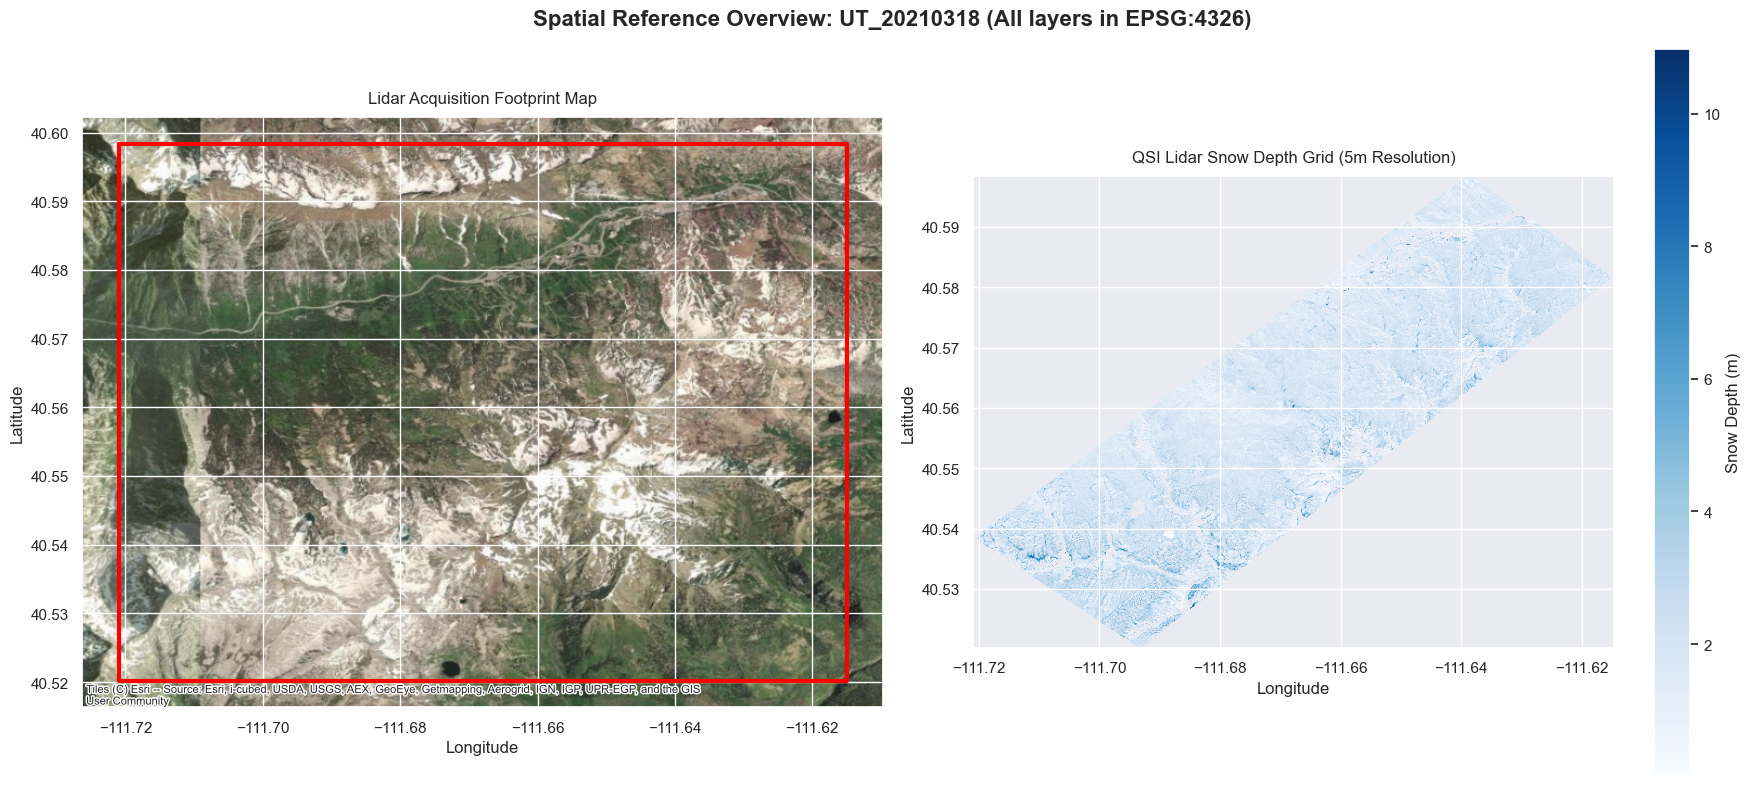

INFO:snow_comparison:Generating aligned reference maps for CO_20210319...
INFO:earthaccess.store:Opening 1 granules, approx size: 0.19 GB
QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 3557.51it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.58s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 16980.99it/s]
INFO:snow_comparison:Reprojecting and downsampling Lidar to 5m resolution in EPSG:4326...


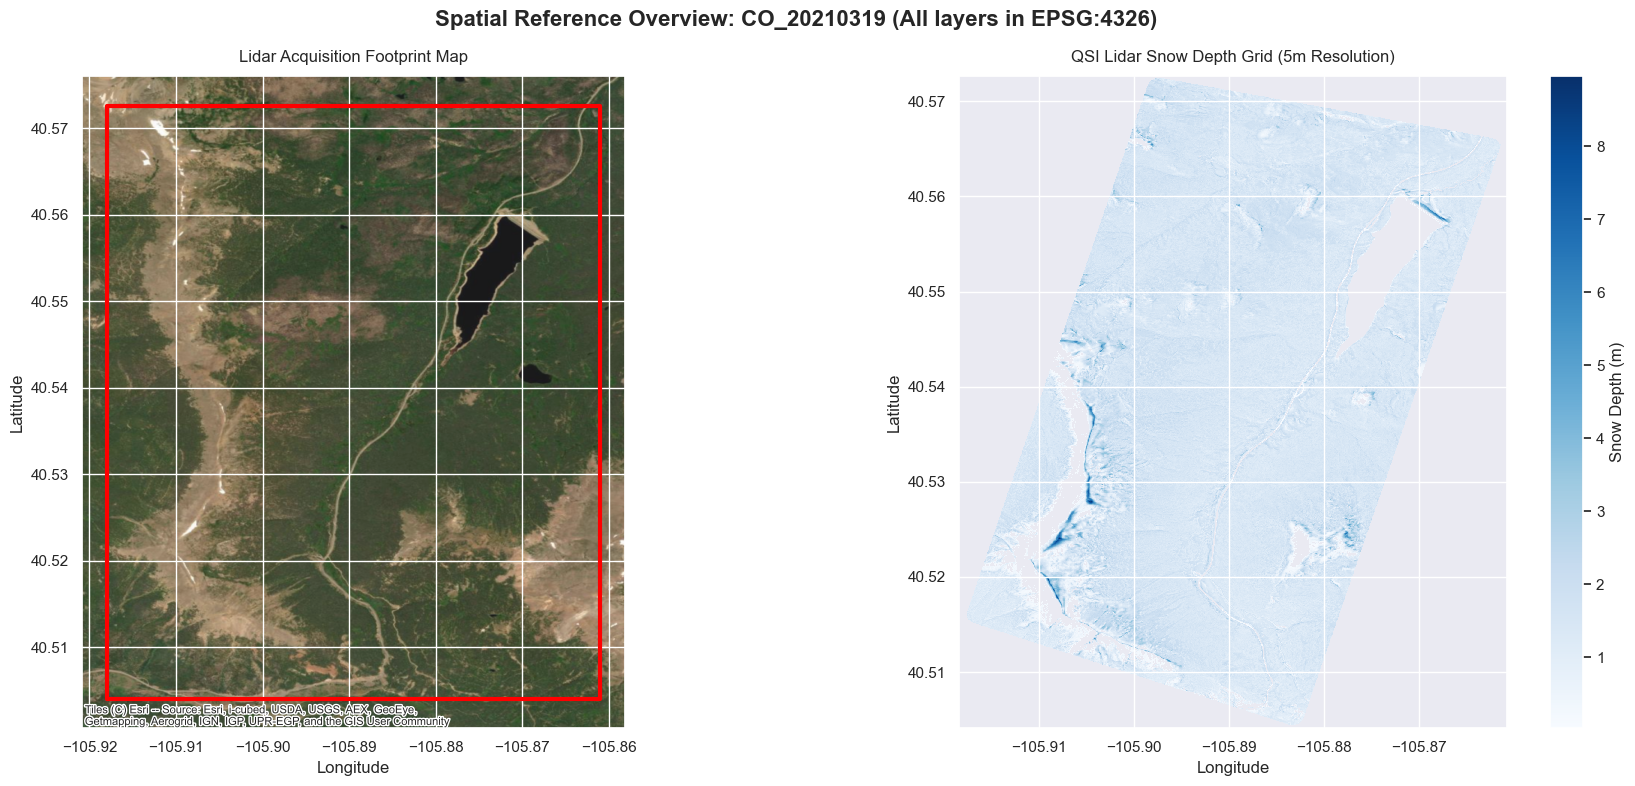

In [14]:

for site_id, info in sites_data.items():
    logger.info(f"Generating aligned reference maps for {site_id}...")
    
    # 1. Open the original high-resolution Lidar dataset
    lidar_file = earthaccess.open([info['granule']])[0]
    da_lidar = rxa.open_rasterio(lidar_file, chunks={'x': 2000, 'y': 2000}).squeeze()
    da_lidar = da_lidar.where(da_lidar >= 0)  # Filter out nodata values
    
    # 2. Downsample and reproject the Lidar dataset to EPSG:4326 at ~5m spacing
    # 5 meters is approximately 0.000045 degrees in geographic coordinates
    target_crs = "EPSG:4326"
    target_resolution = 0.000045 
    
    logger.info(f"Reprojecting and downsampling Lidar to 5m resolution in {target_crs}...")
    da_lidar_5m = da_lidar.rio.reproject(
        dst_crs=target_crs,
        resolution=target_resolution,
        resampling=Resampling.average
    )
    
    # 3. Create a GeoDataFrame for the bounding footprint in EPSG:4326
    gdf_bbox = gpd.GeoDataFrame(geometry=[info['polygon']], crs="EPSG:4326")
    
    # 4. Build a Side-by-Side (1 Row, 2 Columns) Layout
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle(f"Spatial Reference Overview: {site_id} (All layers in EPSG:4326)", fontsize=16, weight='bold')
    
    # --- Axis 1: Satellite Imagery Footprint Outline ---
    gdf_bbox.plot(ax=axes[0], facecolor="none", edgecolor="red", linewidth=3, label="Lidar Footprint")
    
    # contextily expects a web basemap projection, but passing crs="EPSG:4326" 
    # tells it to warp the background image tiles into WGS84 Lat/Lon automatically
    cx.add_basemap(
        axes[0], 
        crs=target_crs, 
        source=cx.providers.Esri.WorldImagery,
        alpha=0.9
    )
    axes[0].set_title("Lidar Acquisition Footprint Map", fontsize=12, pad=10)
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    
    # --- Axis 2: 5m Lidar Map in EPSG:4326 ---
    da_lidar_5m.plot.imshow(
        ax=axes[1], 
        x='x',
        y='y',
        cmap='Blues', 
        cbar_kwargs={'label': 'Snow Depth (m)'}
    )
    axes[1].set_title("QSI Lidar Snow Depth Grid (5m Resolution)", fontsize=12, pad=10)
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")
    
    # Match the aspect ratios so spatial geometries don't distort skewing east/west
    for ax in axes:
        ax.set_aspect('equal', 'box')
        
    plt.tight_layout()
    plt.show()

## Compare! 

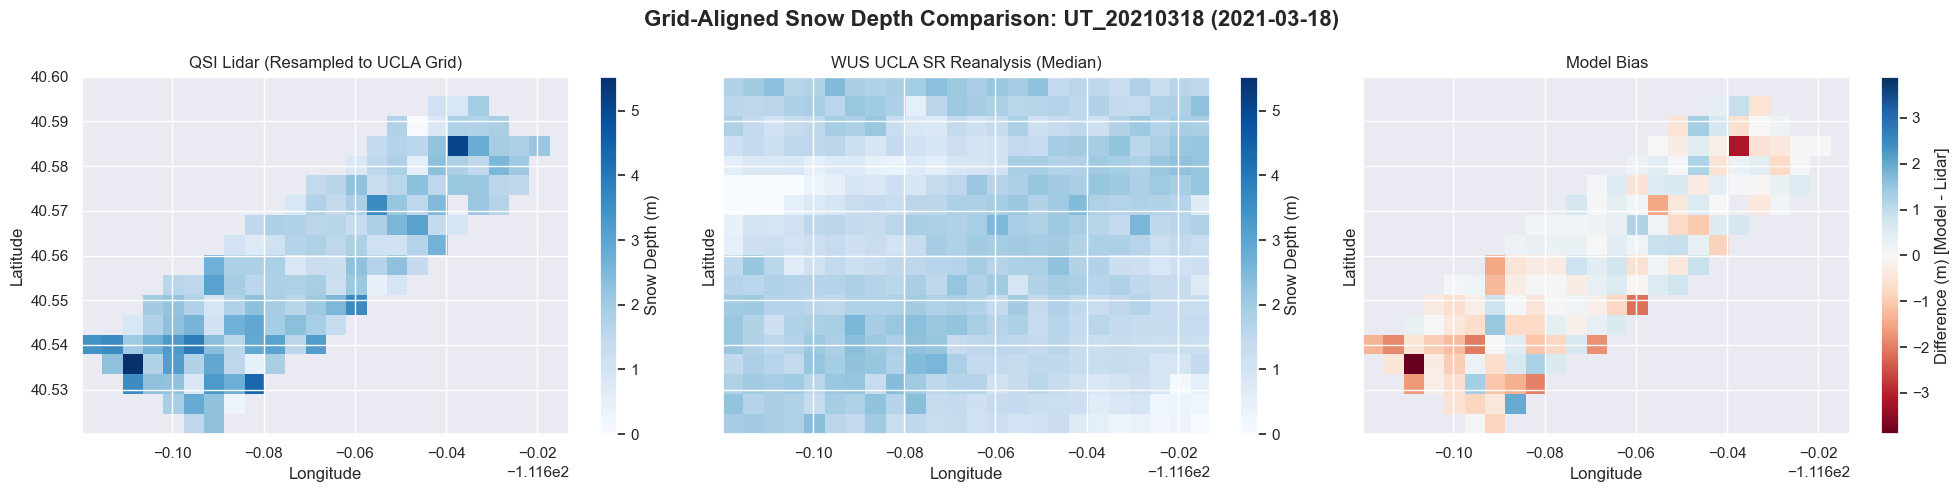

--- Statistics for UT_20210318 ---
Mean Bias (UCLA - Lidar): -0.131 meters
Root Mean Square Error (RMSE): 0.839 meters



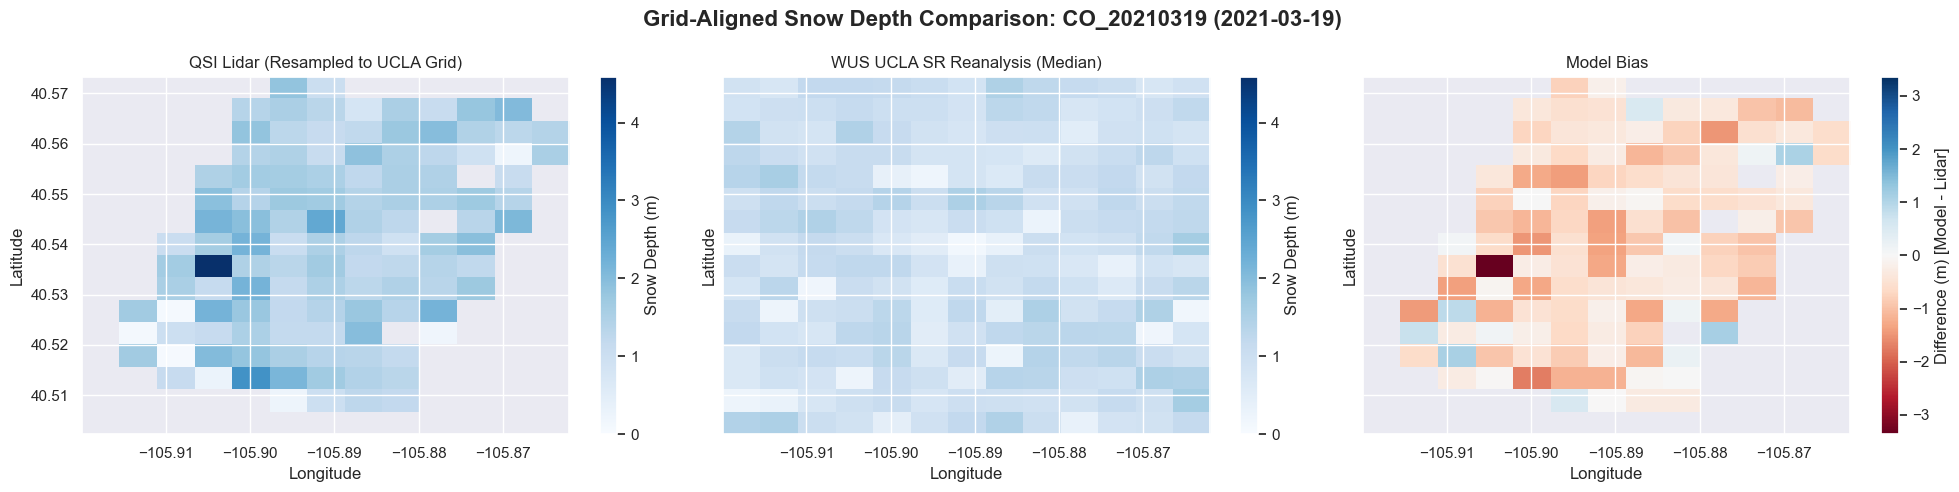

--- Statistics for CO_20210319 ---
Mean Bias (UCLA - Lidar): -0.539 meters
Root Mean Square Error (RMSE): 0.813 meters



In [15]:
# Styling parameters
COLORMAP_DATA = 'Blues'
COLORMAP_BIAS = 'RdBu'
FIG_SIZE = (20, 5)

for site_id, plot_info in processed_plots_data.items():
    
    # Compute safe color range bounds ignoring NaNs from cached numpy arrays
    lidar_v = plot_info['lidar_vals']
    ucla_v = plot_info['ucla_vals']
    diff_v = plot_info['diff_vals']
    
    vmax = float(max(np.nanmax(lidar_v), np.nanmax(ucla_v))) if not np.all(np.isnan(lidar_v)) else 2.0
    div_max = float(np.nanmax(np.abs(diff_v))) if not np.all(np.isnan(diff_v)) else 1.0

    fig, axes = plt.subplots(1, 3, figsize=FIG_SIZE, sharex=True, sharey=True)
    fig.suptitle(f"Grid-Aligned Snow Depth Comparison: {site_id} ({plot_info['date']})", fontsize=16, weight='bold')
    
    # Panel 1: Aligned QSI Lidar Ground Truth
    plot_info['lidar_aligned'].plot.imshow(
        ax=axes[0], x='x', y='y', cmap=COLORMAP_DATA, vmin=0, vmax=vmax, 
        cbar_kwargs={'label': 'Snow Depth (m)'}
    )
    axes[0].set_title("QSI Lidar (Resampled to UCLA Grid)")
    
    # Panel 2: UCLA Reanalysis Model Grid (Ensemble Median)
    plot_info['ucla_snow'].plot.imshow(
        ax=axes[1], x='x', y='y', cmap=COLORMAP_DATA, vmin=0, vmax=vmax, 
        cbar_kwargs={'label': 'Snow Depth (m)'}
    )
    axes[1].set_title("WUS UCLA SR Reanalysis (Median)")
    
    # Panel 3: Spatial Bias Map Residuals (Model - Truth)
    plot_info['difference'].plot.imshow(
        ax=axes[2], x='x', y='y', cmap=COLORMAP_BIAS, vmin=-div_max, vmax=div_max, 
        cbar_kwargs={'label': 'Difference (m) [Model - Lidar]'}
    )
    axes[2].set_title("Model Bias")
    
    # Standardize map labels
    for ax in axes:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        
    plt.tight_layout()
    plt.show()
    
    # Print out bulk grid metrics
    bias = float(np.nanmean(diff_v))
    rmse = float(np.sqrt(np.nanmean(diff_v ** 2)))
    print(f"--- Statistics for {site_id} ---")
    print(f"Mean Bias (UCLA - Lidar): {bias:.3f} meters")
    print(f"Root Mean Square Error (RMSE): {rmse:.3f} meters\n")

## Elevation Band Bias Assessment
This section downloads a DEM with `py3dep`, aligns it to the lidar/model comparison grid, and summarizes model bias in 20% elevation quantile bands. Only pixels where the lidar-aligned data are valid are included in the elevation spread and bias calculations.

INFO:snow_comparison:Downloading DEM for UT_20210318 with py3dep...
INFO:rasterio.session:boto3 not available, falling back to a DummySession.
INFO:snow_comparison:Downloading DEM for CO_20210319 with py3dep...
INFO:rasterio.session:boto3 not available, falling back to a DummySession.


,site_id,band,elevation_low_m,elevation_high_m,count,mean_bias_m,median_bias_m,rmse_m
0,UT_20210318,2459-2744 m,2459.169922,2743.612793,30,0.030910,0.106792,0.739826
1,UT_20210318,2744-2925 m,2743.612793,2925.070654,30,-0.042145,0.043968,0.582564
2,UT_20210318,2925-3019 m,2925.070654,3018.709863,29,-0.150335,0.002495,0.817061
3,UT_20210318,3019-3124 m,3018.709863,3123.823828,30,-0.344821,-0.428748,0.976256
4,UT_20210318,3124-3371 m,3123.823828,3370.724609,30,-0.149873,0.012161,1.004144
5,CO_20210319,2961-3096 m,2961.118408,3096.425293,23,-0.422172,-0.386015,0.642691
6,CO_20210319,3096-3161 m,3096.425293,3160.932373,23,-0.460410,-0.432224,0.575398
7,CO_20210319,3161-3231 m,3160.932373,3230.896729,23,-0.755629,-0.853260,0.870494
8,CO_20210319,3231-3318 m,3230.896729,3318.479980,23,-0.576398,-0.549035,0.724734
9,CO_20210319,3318-3511 m,3318.479980,3510.732666,24,-0.484037,-0.275612,1.118037


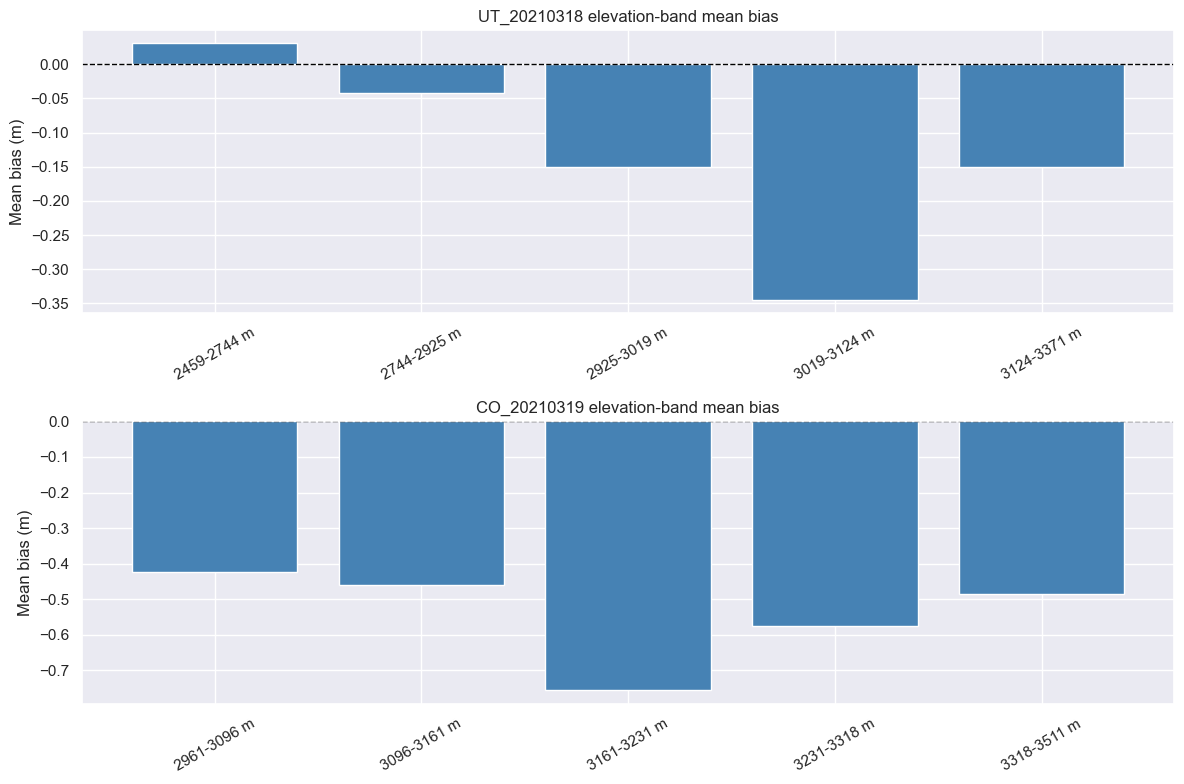

In [22]:
# Elevation-band model bias using a DEM downloaded with py3dep
elevation_band_results = {}
elevation_band_summary = []

for site_id, plot_info in processed_plots_data.items():
    minx, miny, maxx, maxy = sites_data[site_id]['bbox_coords']
    lidar_da = plot_info['lidar_aligned']
    model_da = plot_info['ucla_snow']
    bias_da = plot_info['difference']

    logger.info(f"Downloading DEM for {site_id} with py3dep...")
    try:
        dem = py3dep.get_dem((minx, miny, maxx, maxy), 10)
    except Exception as exc:
        logger.error(f"py3dep DEM download failed for {site_id}: {exc}")
        raise

    if isinstance(dem, xr.Dataset):
        dem_da = dem[list(dem.data_vars)[0]]
    else:
        dem_da = dem

    dem_da = dem_da.squeeze()
    if dem_da.rio.crs is None:
        dem_da = dem_da.rio.write_crs("EPSG:4326")
    dem_da = dem_da.rio.reproject_match(lidar_da)

    valid_mask = np.isfinite(lidar_da) & np.isfinite(model_da) & np.isfinite(dem_da)
    elevation_values = dem_da.where(valid_mask).values
    elevation_values = elevation_values[np.isfinite(elevation_values)]

    if elevation_values.size == 0:
        logger.warning(f"No valid overlap between lidar and DEM for {site_id}; skipping elevation-band summary.")
        continue

    quantile_edges = np.nanquantile(elevation_values, np.linspace(0, 1, 6))
    quantile_edges = np.unique(quantile_edges)

    if quantile_edges.size < 2:
        logger.warning(f"DEM elevation range is too small to build bands for {site_id}.")
        continue

    site_rows = []
    for band_index in range(len(quantile_edges) - 1):
        low = float(quantile_edges[band_index])
        high = float(quantile_edges[band_index + 1])
        if band_index == len(quantile_edges) - 2:
            band_mask = (dem_da >= low) & (dem_da <= high) & valid_mask
        else:
            band_mask = (dem_da >= low) & (dem_da < high) & valid_mask

        band_bias = bias_da.where(band_mask)
        band_bias_local = band_bias.compute()
        valid_count = int(band_bias_local.count().item())
        if valid_count == 0:
            continue

        site_rows.append({
            'site_id': site_id,
            'band': f"{low:.0f}-{high:.0f} m",
            'elevation_low_m': low,
            'elevation_high_m': high,
            'count': valid_count,
            'mean_bias_m': float(band_bias_local.mean(skipna=True).item()),
            'median_bias_m': float(band_bias_local.median(skipna=True).item()),
            'rmse_m': float(np.sqrt((band_bias_local ** 2).mean(skipna=True).item()))
        })

    elevation_band_results[site_id] = pd.DataFrame(site_rows)
    if not elevation_band_results[site_id].empty:
        elevation_band_summary.append(elevation_band_results[site_id])

if elevation_band_summary:
    elevation_band_summary_df = pd.concat(elevation_band_summary, ignore_index=True)
    display(elevation_band_summary_df)

    n_sites = len(elevation_band_results)
    fig, axes = plt.subplots(n_sites, 1, figsize=(12, max(4, 4 * n_sites)), sharex=False)
    if n_sites == 1:
        axes = [axes]

    for ax, (site_id, summary_df) in zip(axes, elevation_band_results.items()):
        if summary_df.empty:
            ax.set_title(f"{site_id} - no elevation-band data")
            continue
        ax.bar(summary_df['band'], summary_df['mean_bias_m'], color='steelblue')
        ax.axhline(0, color='black', linewidth=1, linestyle='--')
        ax.set_title(f"{site_id} elevation-band mean bias")
        ax.set_ylabel('Mean bias (m)')
        ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()
else:
    logger.warning("No elevation-band summaries were produced.")

## SNOTEL Timeseries Comparison
This section fetches station records from the SNOTEL network for stations near each lidar footprint, clips them to the target date windows defined earlier, and stores them in `snotel_timeseries_data`. The timeseries are later plotted alongside WUS-derived snow depth and SWE for direct comparison.

Notes: `easysnowdata` is used to access station metadata and historical records; ensure network access for downloads or pre-download station tables to avoid repeated queries.

In [16]:
import easysnowdata as esd 
from shapely.geometry import box

In [17]:
snotels = esd.automatic_weather_stations.StationCollection()
snotels.all_stations

Geodataframe with all stations has been added to the Station object. Please use the .all_stations attribute to access.
Use the .get_data(stations=geodataframe/string/list,variables=string/list,start_date=str,end_date=str) method to fetch data for specific stations and variables.


,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
code,,,,,,,,,,,,,
301_CA_SNTL,Adin Mtn,SNOTEL,1886.712036,41.235828,-120.791924,California,180200021403,10TFL,Great Basin Ranges,1983-10-01,2026-06-02,True,POINT (-120.79192 41.23583)
907_UT_SNTL,Agua Canyon,SNOTEL,2712.719971,37.522171,-112.271179,Utah,160300020301,12SUG,Colorado Plateau,1994-10-01,2026-06-02,True,POINT (-112.27118 37.52217)
916_MT_SNTL,Albro Lake,SNOTEL,2529.840088,45.597229,-111.959023,Montana,100200050701,12TVR,Central Montana Rocky Mountains,1996-09-01,2026-06-02,True,POINT (-111.95902 45.59723)
1267_AK_SNTL,Alexander Lake,SNOTEL,48.768002,61.749668,-150.889664,Alaska,190205051106,05VPJ,None,2014-08-28,2026-06-02,True,POINT (-150.88966 61.74967)
908_WA_SNTL,Alpine Meadows,SNOTEL,1066.800049,47.779572,-121.698471,Washington,171100100501,10TET,Cascade Range,1994-09-01,2026-06-02,True,POINT (-121.69847 47.77957)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
SLT,Slate Creek,CCSS,1737.360000,41.043980,-122.480103,California,180200050304,10TEL,Klamath Mountains,2004-10-01,2026-06-02,True,POINT (-122.4801 41.04398)
SLI,Slide Canyon,CCSS,2804.160000,38.091234,-119.431881,California,180400090501,11SKC,Sierra Nevada,2005-10-01,2026-06-02,True,POINT (-119.43188 38.09123)
SLK,South Lake,CCSS,2926.080000,37.175903,-118.562660,California,180901020601,11SLB,Sierra Nevada,2004-10-01,2026-06-02,True,POINT (-118.56266 37.1759)


INFO:snow_comparison:Plotting SNOTEL proximity footprint for UT_20210318 on subplot axis 0...
/var/folders/vr/54bwt92x0tq5_lsckcv161380000gp/T/ipykernel_22355/1251345130.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  intersecting_snotels = snotels_3857[snotels_3857.intersects(gdf_lidar_buffered.unary_union)]
INFO:snow_comparison:Plotting SNOTEL proximity footprint for CO_20210319 on subplot axis 1...
/var/folders/vr/54bwt92x0tq5_lsckcv161380000gp/T/ipykernel_22355/1251345130.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  intersecting_snotels = snotels_3857[snotels_3857.intersects(gdf_lidar_buffered.unary_union)]


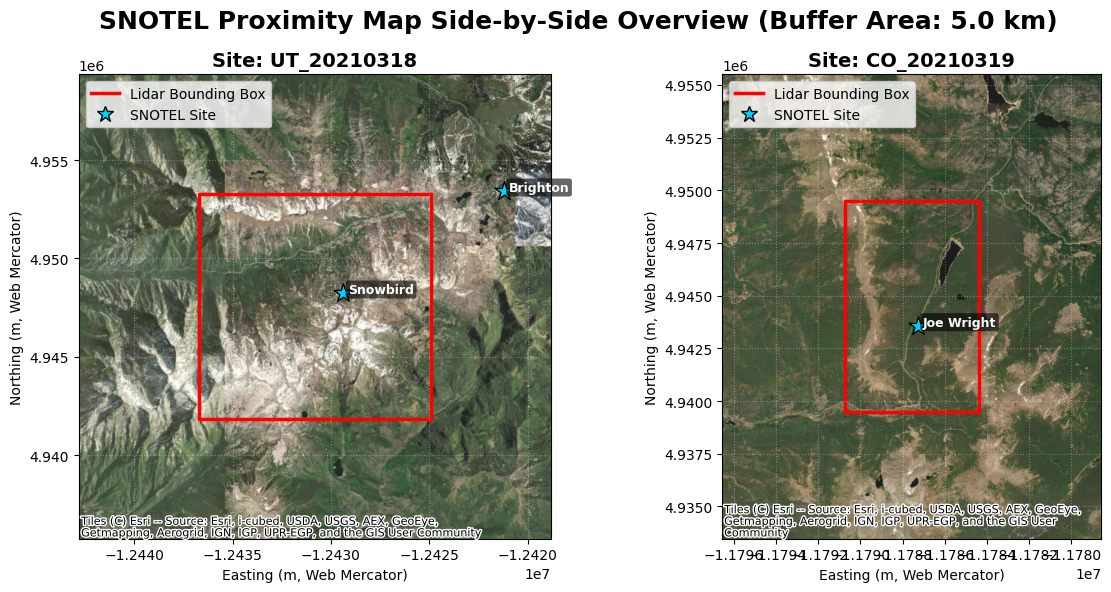

In [18]:
from matplotlib.lines import Line2D

# --- ADJUSTABLE PARAMETERS ---
BUFFER_METERS = 5000  # Expand/contract the SNOTEL search radius (in meters)
FIG_SIZE = (12, 6)    # Wide figure size to hold two maps side-by-side
# -----------------------------

# Ensure your master snotels dataframe is projected to Web Mercator for meter calculations
snotels_3857 = snotels.all_stations.to_crs("EPSG:3857")

# Initialize a single 1-row, 2-column layout for the two sites
fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
fig.suptitle(f"SNOTEL Proximity Map Side-by-Side Overview (Buffer Area: {BUFFER_METERS/1000:.1f} km)", 
             fontsize=18, weight='bold', y=0.98)

# Loop through the items and use enumerate to place them in axes[0] and axes[1]
for idx, (site_id, info) in enumerate(sites_data.items()):
    ax = axes[idx]
    logger.info(f"Plotting SNOTEL proximity footprint for {site_id} on subplot axis {idx}...")
    
    # 1. Setup Geometries in Web Mercator (EPSG:3857)
    gdf_lidar_core = gpd.GeoDataFrame(geometry=[info['polygon']], crs="EPSG:4326").to_crs("EPSG:3857")
    gdf_lidar_buffered = gpd.GeoDataFrame(geometry=gdf_lidar_core.buffer(BUFFER_METERS), crs="EPSG:3857")
    
    # 2. Extract SNOTEL sites within the buffer area
    intersecting_snotels = snotels_3857[snotels_3857.intersects(gdf_lidar_buffered.unary_union)]
    
    # 3. Plot Layer 1: The Expanded Buffer Search Zone (dashed gray)
    gdf_lidar_buffered.plot(
        ax=ax, facecolor="none", edgecolor="none", linestyle="--", linewidth=1.5
    )
    
    # Plot Layer 2: The Core Lidar footprint (solid red)
    gdf_lidar_core.plot(
        ax=ax, facecolor="none", edgecolor="red", linewidth=2.5
    )
    
    # Plot Layer 3: Intersecting SNOTEL Sites (bright blue stars)
    if not intersecting_snotels.empty:
        intersecting_snotels.plot(
            ax=ax, color="#00d2ff", marker="*", markersize=200, edgecolor="black", linewidth=1, zorder=5
        )
        
        # Annotate each SNOTEL station on the fly with its name
        for _, row in intersecting_snotels.iterrows():
            name_col = 'station_name' if 'station_name' in row else 'name'
            ax.text(
                row.geometry.x + (BUFFER_METERS * 0.05), 
                row.geometry.y, 
                str(row[name_col]), 
                fontsize=9, color="white", weight="bold", zorder=6,
                bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2')
            )
            
    # Plot Layer 4: Stream the background Satellite Imagery 
    cx.add_basemap(ax, crs="EPSG:3857", source=cx.providers.Esri.WorldImagery, alpha=0.9)
    
    # Individual Map Layout Customizations
    ax.set_title(f"Site: {site_id}", fontsize=14, weight='bold')
    ax.set_xlabel("Easting (m, Web Mercator)")
    ax.set_ylabel("Northing (m, Web Mercator)")
    ax.grid(True, linestyle=":", alpha=0.3, color="white")
    ax.set_aspect('equal', 'box')  # Protects maps from stretching distortions
    
    # Add a clean legend to each plot window
    legend_elements = [
        Line2D([0], [0], color='red', lw=2.5, label='Lidar Bounding Box'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='#00d2ff', markeredgecolor='black', markersize=12, label='SNOTEL Site', linestyle='None')
    ]
    ax.legend(handles=legend_elements, loc='upper left', framealpha=0.8)

plt.tight_layout()
plt.show()

In [19]:
snotel_mapping = {
    'CO': {'triplet': '551_CO_SNTL', 'name': 'Joe Wright'},
    'UT': {'triplet': '766_UT_SNTL', 'name': 'Snowbird'}
}

# Define our target evaluation windows across both winter seasons
date_ranges = [
    {'start': '2019-12-01', 'end': '2020-04-01', 'label': 'Winter_2020'},
    {'start': '2020-12-01', 'end': '2021-04-01', 'label': 'Winter_2021'}
]

# Create a clean dictionary container to store your final timeseries arrays
snotel_timeseries_data = {}

for site_id, station in snotel_mapping.items():
    snotel_timeseries_data[site_id] = {}
    logger.info(f"Fetching full historical table for SNOTEL: {station['name']} ({station['triplet']})...")
    
    # Fetch the entire historical table using your snotels instance method
    sntl = esd.automatic_weather_stations.StationCollection()
    sntl.get_data(station['triplet'])  # This should return a DataFrame with a datetime index
    df_full = sntl.data
    
    # Ensure the index is explicitly formatted as a DatetimeIndex so slicing works perfectly
    df_full.index = pd.to_datetime(df_full.index)
    
    for period in date_ranges:
        # Slice the full dataframe to the specific window bounds
        df_clipped = df_full.loc[period['start']:period['end']]
        
        if not df_clipped.empty:
            snotel_timeseries_data[site_id][period['label']] = df_clipped
            logger.info(f"Successfully clipped {period['label']} data array ({len(df_clipped)} records).")
        else:
            logger.warning(f"No records found for {station['name']} after clipping to {period['label']}.")

print(snotel_timeseries_data)


INFO:snow_comparison:Fetching full historical table for SNOTEL: Joe Wright (551_CO_SNTL)...


Geodataframe with all stations has been added to the Station object. Please use the .all_stations attribute to access.
Use the .get_data(stations=geodataframe/string/list,variables=string/list,start_date=str,end_date=str) method to fetch data for specific stations and variables.
Only one station chosen with variables=None. Default behavior fetches all variables for this station.


INFO:snow_comparison:Successfully clipped Winter_2020 data array (123 records).
INFO:snow_comparison:Successfully clipped Winter_2021 data array (122 records).
INFO:snow_comparison:Fetching full historical table for SNOTEL: Snowbird (766_UT_SNTL)...


Dataframe has been added to the Station object. Please use the .data attribute to access.
Geodataframe with all stations has been added to the Station object. Please use the .all_stations attribute to access.
Use the .get_data(stations=geodataframe/string/list,variables=string/list,start_date=str,end_date=str) method to fetch data for specific stations and variables.
Only one station chosen with variables=None. Default behavior fetches all variables for this station.


INFO:snow_comparison:Successfully clipped Winter_2020 data array (123 records).
INFO:snow_comparison:Successfully clipped Winter_2021 data array (122 records).


Dataframe has been added to the Station object. Please use the .data attribute to access.
{'CO': {'Winter_2020':             TAVG  TMIN  TMAX    SNWD    WTEQ  PRCPSA
datetime                                            
2019-12-01  -8.1 -13.5  -0.5  0.4826  0.1016  0.0025
2019-12-02  -0.8  -3.0   2.9  0.4572  0.1016  0.0025
2019-12-03  -3.0  -6.1  -1.3  0.4572  0.1041  0.0000
2019-12-04  -1.5  -4.2   1.0  0.4318  0.1041  0.0000
2019-12-05  -2.3  -3.6  -0.4  0.4318  0.1041  0.0203
...          ...   ...   ...     ...     ...     ...
2020-03-28  -8.3 -13.1  -3.4  1.8542  0.5639  0.0000
2020-03-29  -5.2 -11.1   0.7  1.8034  0.5639  0.0000
2020-03-30  -3.2 -11.1   4.1  1.7272  0.5639  0.0000
2020-03-31   1.0  -3.1   6.2  1.7272  0.5639  0.0000
2020-04-01   3.9   0.6   8.4  1.7272  0.5639  0.0000

[123 rows x 6 columns], 'Winter_2021':             TAVG  TMIN  TMAX    SNWD    WTEQ  PRCPSA
datetime                                            
2020-12-01  -9.0 -13.8  -3.8  0.4318  0.1143  0.0127

In [43]:
# Pull WUS_UCLA_SR time series for the same windows used by the modeled comparison
wus_timeseries_data = {}

for site_id, info in sites_data.items():
    minx, miny, maxx, maxy = info['bbox_coords']

    logger.info(f"Building WUS_UCLA_SR time series for {site_id}...")
    wus_timeseries_data[site_id] = {}

    for period in date_ranges:
        logger.info(f"Searching WUS_UCLA_SR data for {site_id} in {period['label']} ({period['start']} to {period['end']})...")

        try:
            wus_grans = earthaccess.search_data(
                short_name='WUS_UCLA_SR',
                cloud_hosted=True,
                temporal=(period['start'], period['end']),
                bounding_box=(minx, miny, maxx, maxy)
            )
        except Exception as exc:
            logger.error(f"earthaccess.search_data failed for WUS_UCLA_SR: {exc}")
            raise

        wus_fileset = earthaccess.open(wus_grans)
        sd_files = [f for f in wus_fileset if "SD_POST" in (f.path if hasattr(f, 'path') else str(f))]
        swe_files = [f for f in wus_fileset if "SWE_SCA_POST" in (f.path if hasattr(f, 'path') else str(f))]

        if not sd_files:
            logger.warning(f"No matching SD_POST files found for {site_id} in {period['label']}.")
            continue
        if not swe_files:
            logger.warning(f"No matching SWE_POST files found for {site_id} in {period['label']}.")
            continue

        # Helper to build a tidy dataframe from WUS granule files for a named variable
        def _build_wus_df(files, varname, out_name):
            if not files:
                return None
            processed = []
            for f in files:
                filename = f.path if hasattr(f, 'path') else str(f)
                ds = xr.open_dataset(f, chunks={})
                try:
                    start_year = int(re.search(r'WY(\d{4})_\d{2}', filename).group(1))
                except Exception:
                    # Fallback: use overall period start year
                    start_year = pd.to_datetime(period['start']).year
                time_coords = pd.date_range(start=f"{start_year}-10-01", periods=ds.sizes.get('Day', ds.sizes.get('time', 0)), freq='D')

                # Standardize spatial coord arrays
                if 'Latitude' in ds.coords or 'Latitude' in ds:
                    lat_vals = ds.Latitude.values.flatten() if 'Latitude' in ds else ds['y'].values.flatten()
                else:
                    lat_vals = ds.y.values.flatten() if 'y' in ds.coords else []
                if 'Longitude' in ds.coords or 'Longitude' in ds:
                    lon_vals = ds.Longitude.values.flatten() if 'Longitude' in ds else ds['x'].values.flatten()
                else:
                    lon_vals = ds.x.values.flatten() if 'x' in ds.coords else []

                ds = ds.rename({'Day': 'time', 'Latitude': 'y', 'Longitude': 'x'})
                if len(time_coords) > 0:
                    ds = ds.assign_coords(time=time_coords)
                if len(lat_vals) > 0:
                    ds = ds.assign_coords(y=lat_vals)
                if len(lon_vals) > 0:
                    ds = ds.assign_coords(x=lon_vals)
                processed.append(ds)
            if not processed:
                return None
            ds_all = xr.concat(processed, dim='time').sortby('time')
            period_ds = ds_all.sel(time=slice(period['start'], period['end']))
            if period_ds.time.size == 0:
                return None
            da = period_ds[varname] if varname in period_ds.data_vars else period_ds[list(period_ds.data_vars)[0]]
            spatial_dims = [dim for dim in ('x', 'y') if dim in da.dims]
            if spatial_dims:
                da = da.mean(dim=spatial_dims, skipna=True)
            for dim in [d for d in da.dims if d != 'time']:
                da = da.isel({dim: 0})
            return da.to_dataframe(name=out_name).reset_index()

        snow_df = _build_wus_df(sd_files, 'SD_POST', 'snow_depth')
        swe_df = _build_wus_df(swe_files, 'SWE_POST', 'swe')

        # Merge results, favoring outer join so we keep all observations
        if snow_df is None and swe_df is None:
            logger.warning(f"No usable WUS variables found for {site_id} in {period['label']}.")
            continue
        elif snow_df is None:
            merged = swe_df.copy()
            merged['snow_depth'] = pd.NA
        elif swe_df is None:
            merged = snow_df.copy()
            merged['swe'] = pd.NA
        else:
            merged = pd.merge(snow_df, swe_df, on='time', how='outer')

        merged = merged.sort_values('time').reset_index(drop=True)
        wus_timeseries_data[site_id][period['label']] = merged
        logger.info(f"Stored WUS_UCLA_SR time series for {site_id} / {period['label']} ({len(merged)} rows).")

print(wus_timeseries_data)

INFO:snow_comparison:Building WUS_UCLA_SR time series for UT_20210318...
INFO:snow_comparison:Searching WUS_UCLA_SR data for UT_20210318 in Winter_2020 (2019-12-01 to 2020-04-01)...
INFO:earthaccess.api:Granules found: 2
INFO:earthaccess.store:Opening 2 granules, approx size: 0.26 GB
QUEUEING TASKS | : 100%|██████████| 2/2 [00:00<00:00, 343.40it/s]
PROCESSING TASKS | : 100%|██████████| 2/2 [00:01<00:00,  1.30it/s]
COLLECTING RESULTS | : 100%|██████████| 2/2 [00:00<00:00, 31184.42it/s]
INFO:fsspec:BlockCache fetching block (sync) 0
INFO:fsspec:BlockCache fetching block (async) 1
INFO:fsspec:BlockCache fetching block (sync) 24
INFO:fsspec:BlockCache joined background fetch without waiting.
INFO:fsspec:BlockCache fetching block (async) 25
INFO:fsspec:BlockCache fetching block (async) 9
INFO:fsspec:BlockCache fetching block (async) 14
INFO:fsspec:BlockCache fetching block (async) 3
INFO:fsspec:BlockCache fetching block (async) 16
INFO:fsspec:BlockCache fetching block (async) 17
INFO:fsspec

{'UT_20210318': {'Winter_2020':           time  snow_depth       swe
0   2019-12-01    0.134074  0.022853
1   2019-12-02    0.120297  0.022612
2   2019-12-03    0.110431  0.022218
3   2019-12-04    0.101055  0.021545
4   2019-12-05    0.132110  0.025065
..         ...         ...       ...
118 2020-03-28    0.543817  0.188983
119 2020-03-29    0.543253  0.189900
120 2020-03-30    0.538535  0.189942
121 2020-03-31    0.521630  0.187840
122 2020-04-01    0.500179  0.183883

[123 rows x 3 columns], 'Winter_2021':           time  snow_depth       swe
0   2020-12-01    0.057387  0.015817
1   2020-12-02    0.057075  0.015793
2   2020-12-03    0.056338  0.015721
3   2020-12-04    0.054876  0.015534
4   2020-12-05    0.053198  0.015323
..         ...         ...       ...
117 2021-03-28    0.365655  0.127902
118 2021-03-29    0.347299  0.124797
119 2021-03-30    0.341866  0.124246
120 2021-03-31    0.335455  0.123579
121 2021-04-01    0.320969  0.120892

[122 rows x 3 columns]}, 'CO_20210319':

In [44]:
try: 
    wus_timeseries_data['CO'] = wus_timeseries_data.pop('CO_20210319')
except KeyError:
    logger.error("Expected key 'CO_20210319' not found in wus_timeseries_data. Available keys: "
                 f"{list(wus_timeseries_data.keys())}")
try: 
    wus_timeseries_data['UT'] = wus_timeseries_data.pop('UT_20210318')
except KeyError:
    logger.error("Expected key 'UT_20210318' not found in wus_timeseries_data. Available keys: "
                 f"{list(wus_timeseries_data.keys())}")

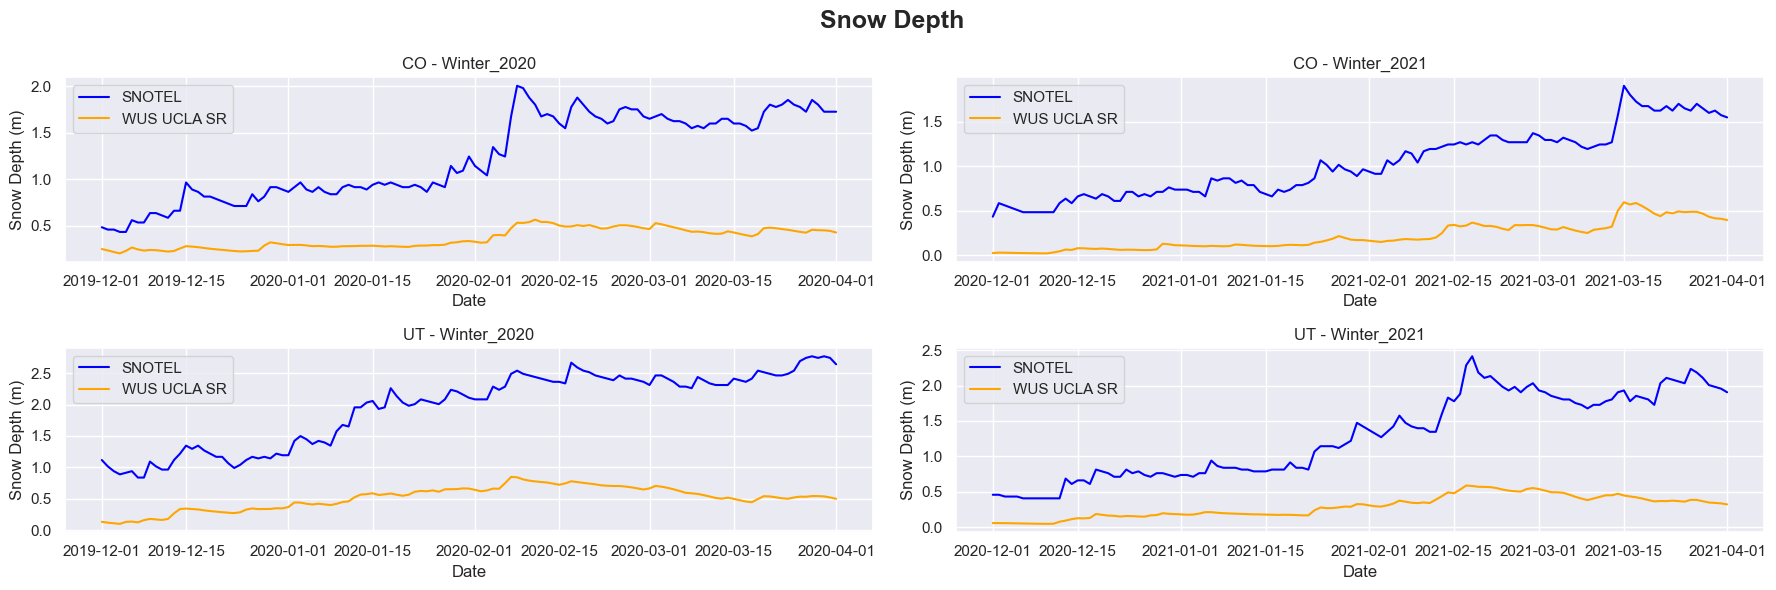

In [48]:
# plot snotel vs wus time series 
fig, ax = plt.subplots(2, 2, figsize=(18, 6))

for idx, site_id in enumerate(snotel_timeseries_data.keys()):
    # print(site_id)
    snotel_data = snotel_timeseries_data[site_id]
    wus_data = wus_timeseries_data.get(site_id, {})
    
    for jdx, period in enumerate(snotel_data.keys()):
        # print(period)
        snotel_df = snotel_data[period]
        wus_df = wus_data.get(period)
        
        if wus_df is not None:
            ax[idx][jdx].plot(snotel_df.index, snotel_df['SNWD'], label='SNOTEL', color='blue')
            ax[idx][jdx].plot(wus_df['time'], wus_df['snow_depth'], label='WUS UCLA SR', color='orange')
            ax[idx][jdx].set_title(f"{site_id} - {period}")
            ax[idx][jdx].set_xlabel("Date")
            ax[idx][jdx].set_ylabel("Snow Depth (m)")
            ax[idx][jdx].legend()
        else:
            ax[idx][jdx].text(0.5, 0.5, 'No WUS Data', horizontalalignment='center', verticalalignment='center')
            ax[idx][jdx].set_title(f"{site_id} - {period}")
            ax[idx][jdx].set_xlabel("Date")
            ax[idx][jdx].set_ylabel("Snow Depth (m)")
# set plot title 
fig.suptitle("Snow Depth", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

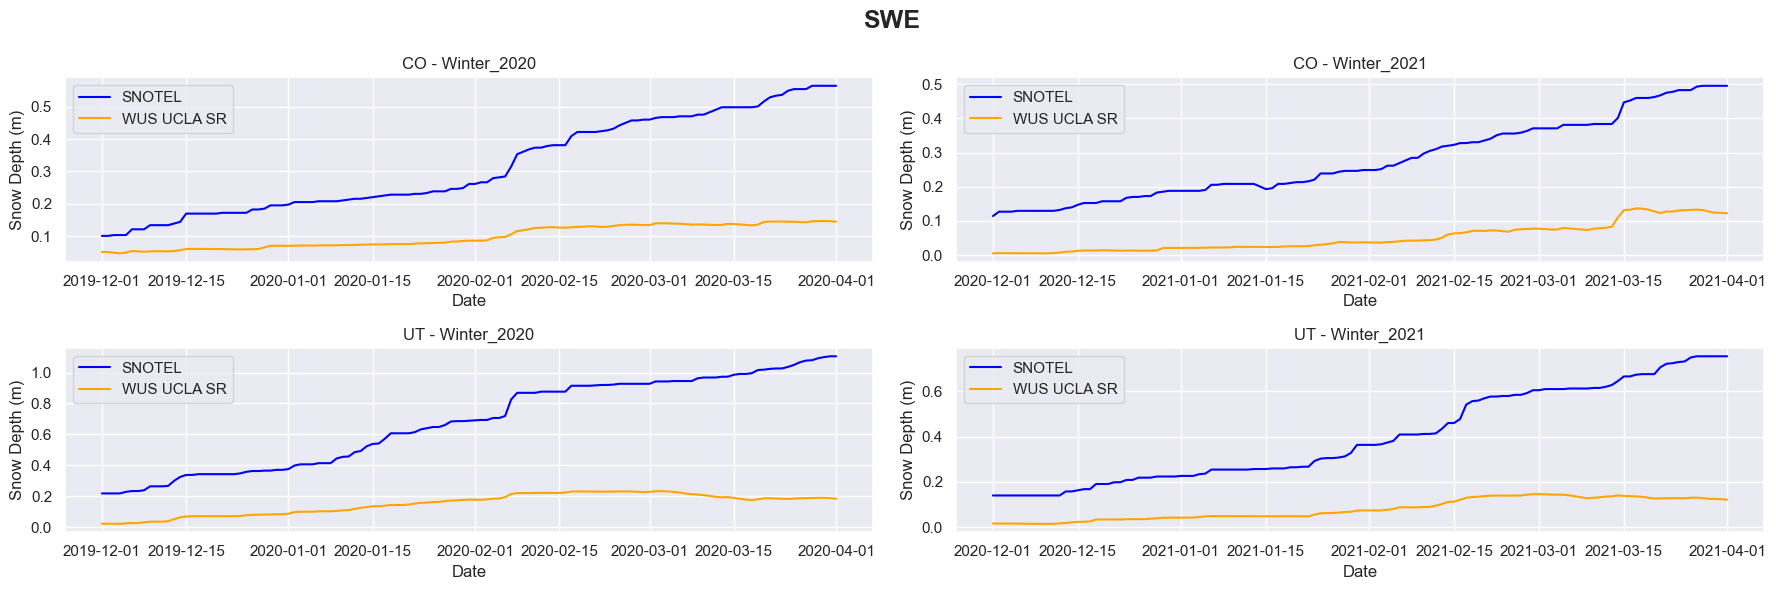

In [49]:
# plot snotel vs wus time series 
fig, ax = plt.subplots(2, 2, figsize=(18, 6))

for idx, site_id in enumerate(snotel_timeseries_data.keys()):
    # print(site_id)
    snotel_data = snotel_timeseries_data[site_id]
    wus_data = wus_timeseries_data.get(site_id, {})
    
    for jdx, period in enumerate(snotel_data.keys()):
        # print(period)
        snotel_df = snotel_data[period]
        wus_df = wus_data.get(period)
        
        if wus_df is not None:
            ax[idx][jdx].plot(snotel_df.index, snotel_df['WTEQ'], label='SNOTEL', color='blue')
            ax[idx][jdx].plot(wus_df['time'], wus_df['swe'], label='WUS UCLA SR', color='orange')
            ax[idx][jdx].set_title(f"{site_id} - {period}")
            ax[idx][jdx].set_xlabel("Date")
            ax[idx][jdx].set_ylabel("Snow Depth (m)")
            ax[idx][jdx].legend()
        else:
            ax[idx][jdx].text(0.5, 0.5, 'No WUS Data', horizontalalignment='center', verticalalignment='center')
            ax[idx][jdx].set_title(f"{site_id} - {period}")
            ax[idx][jdx].set_xlabel("Date")
            ax[idx][jdx].set_ylabel("Snow Depth (m)")

fig.suptitle("SWE", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

# OLD 

In [50]:
base_url = f's3://noaa-nws-aorc-v1-1-1km'

s3_out = s3fs.S3FileSystem(anon=True)
fileset = [s3fs.S3Map(
                root=f"s3://{base_url}/{yr}.zarr", s3=s3_out, check=False
            ) for yr in (2020, 2021)]
full_ds = xr.open_mfdataset(fileset, engine='zarr')

In [51]:
data_dir = '../data/'# on local machine 
mcs_aoi = gpd.read_file(data_dir + 'mores_creek.shp')
mcs_aoi

,id,geometry
0,1,"POLYGON ((-115.6739 43.98328, -115.67315 43.98..."


In [52]:
mcs_lowman_05208_dates = ['200131_200213',
 '200131_200220',
 '200131_200311',
 '200131_210203',
 '200131_210210',
 '200131_210303',
 '200131_210310',
 '200131_210316',
 '200131_210322',
 '200213_200220',
 '200213_200311',
 '200213_210203',
 '200213_210210',
 '200213_210303',
 '200213_210310',
 '200213_210316',
 '200213_210322',
 '200220_200311',
 '200220_210203',
 '200220_210210',
 '200220_210303',
 '200220_210310',
 '200220_210316',
 '200220_210322',
 '200311_210203',
 '200311_210210',
 '200311_210303',
 '200311_210310',
 '200311_210316',
 '200311_210322',
 '210203_210210',
 '210203_210303',
 '210203_210310',
 '210203_210316',
 '210203_210322',
 '210210_210303',
 '210210_210310',
 '210210_210316',
 '210210_210322',
 '210303_210310',
 '210303_210316',
 '210303_210322',
 '210310_210316',
 '210310_210322',
 '210316_210322']

split_dates = [(part[0], part[1]) for part in [d.split('_') for d in mcs_lowman_05208_dates]]
# get all unique individual dates
unique_dates = set([date for pair in split_dates for date in pair])
# convert to datetime objects
mcs_dates = [datetime.strptime(date, '%y%m%d') for date in unique_dates]
print(mcs_dates)

NameError: name 'datetime' is not defined

In [ ]:
minlon, minlat, maxlon, maxlat = mcs_aoi.total_bounds
full_ds = full_ds.rio.clip_box(minx=minlon,
                                    miny=minlat,
                                    maxx=maxlon,
                                    maxy=maxlat)
full_ds

<xarray.Dataset> Size: 146MB
Dimensions:              (latitude: 10, longitude: 13, time: 17544)
Coordinates:
  * latitude             (latitude) float64 80B 43.91 43.92 ... 43.97 43.98
  * longitude            (longitude) float64 104B -115.7 -115.7 ... -115.6
  * time                 (time) datetime64[ns] 140kB 2020-01-01 ... 2021-12-3...
    spatial_ref          int64 8B 0
Data variables:
    APCP_surface         (time, latitude, longitude) float64 18MB dask.array<chunksize=(144, 10, 13), meta=np.ndarray>
    DLWRF_surface        (time, latitude, longitude) float64 18MB dask.array<chunksize=(144, 10, 13), meta=np.ndarray>
    DSWRF_surface        (time, latitude, longitude) float64 18MB dask.array<chunksize=(144, 10, 13), meta=np.ndarray>
    PRES_surface         (time, latitude, longitude) float64 18MB dask.array<chunksize=(144, 10, 13), meta=np.ndarray>
    SPFH_2maboveground   (time, latitude, longitude) float64 18MB dask.array<chunksize=(144, 10, 13), meta=np.ndarray>
    TMP_2maboveground    (time, latitude, longitude) float64 18MB dask.array<chunksize=(144, 10, 13), meta=np.ndarray>
    UGRD_10maboveground  (time, latitude, longitude) float64 18MB dask.array<chunksize=(144, 10, 13), meta=np.ndarray>
    VGRD_10maboveground  (time, latitude, longitude) float64 18MB dask.array<chunksize=(144, 10, 13), meta=np.ndarray>

In [ ]:
# calculate averages over the AOI
ds_means = full_ds.mean(dim=['latitude', 'longitude'])

# do a median filter
ds_means = ds_means.rolling(time=3, center=True).median().compute()
ds_means

<xarray.Dataset> Size: 1MB
Dimensions:              (time: 17544)
Coordinates:
  * time                 (time) datetime64[ns] 140kB 2020-01-01 ... 2021-12-3...
    spatial_ref          int64 8B 0
Data variables:
    APCP_surface         (time) float64 140kB nan 0.0 0.0 ... 0.1 0.07846 nan
    DLWRF_surface        (time) float64 140kB nan 294.3 294.3 ... 229.2 nan
    DSWRF_surface        (time) float64 140kB nan 0.0 0.0 ... 158.7 154.7 nan
    PRES_surface         (time) float64 140kB nan 7.976e+04 ... 7.828e+04 nan
    SPFH_2maboveground   (time) float64 140kB nan 0.0035 ... 0.001573 nan
    TMP_2maboveground    (time) float64 140kB nan 270.0 270.0 ... 263.2 nan
    UGRD_10maboveground  (time) float64 140kB nan 1.298 1.298 ... 2.077 nan
    VGRD_10maboveground  (time) float64 140kB nan 0.1723 0.4492 ... -1.792 nan

In [ ]:
ds_daily = ds_means.resample(time='1D').mean()
ds_daily

<xarray.Dataset> Size: 53kB
Dimensions:              (time: 731)
Coordinates:
  * time                 (time) datetime64[ns] 6kB 2020-01-01 ... 2021-12-31
    spatial_ref          int64 8B 0
Data variables:
    APCP_surface         (time) float64 6kB 1.068 0.05497 0.0 ... 0.5246 0.3418
    DLWRF_surface        (time) float64 6kB 288.0 265.6 241.4 ... 225.3 247.2
    DSWRF_surface        (time) float64 6kB 77.54 72.76 83.66 ... 66.94 38.89
    PRES_surface         (time) float64 6kB 7.91e+04 7.921e+04 ... 7.805e+04
    SPFH_2maboveground   (time) float64 6kB 0.003904 0.002929 ... 0.002009
    TMP_2maboveground    (time) float64 6kB 271.5 269.5 269.9 ... 262.2 264.1
    UGRD_10maboveground  (time) float64 6kB 1.976 1.052 0.6463 ... 2.285 2.759
    VGRD_10maboveground  (time) float64 6kB -0.3168 -0.7942 ... 1.188 -0.3589

In [ ]:
# get daily precip sum
ds_daily['daily_precip'] = ds_means['APCP_surface'].resample(time='1D').sum()
# get temp in deg C
ds_daily['tmp_degC'] = ds_daily['TMP_2maboveground'] - 273.15

ds_daily['wind_mag'] = np.sqrt(ds_daily['UGRD_10maboveground']**2 + ds_daily['VGRD_10maboveground']**2)
ds_daily

<xarray.Dataset> Size: 70kB
Dimensions:              (time: 731)
Coordinates:
  * time                 (time) datetime64[ns] 6kB 2020-01-01 ... 2021-12-31
    spatial_ref          int64 8B 0
Data variables:
    APCP_surface         (time) float64 6kB 1.068 0.05497 0.0 ... 0.5246 0.3418
    DLWRF_surface        (time) float64 6kB 288.0 265.6 241.4 ... 225.3 247.2
    DSWRF_surface        (time) float64 6kB 77.54 72.76 83.66 ... 66.94 38.89
    PRES_surface         (time) float64 6kB 7.91e+04 7.921e+04 ... 7.805e+04
    SPFH_2maboveground   (time) float64 6kB 0.003904 0.002929 ... 0.002009
    TMP_2maboveground    (time) float64 6kB 271.5 269.5 269.9 ... 262.2 264.1
    UGRD_10maboveground  (time) float64 6kB 1.976 1.052 0.6463 ... 2.285 2.759
    VGRD_10maboveground  (time) float64 6kB -0.3168 -0.7942 ... 1.188 -0.3589
    daily_precip         (time) float64 6kB 24.57 1.319 0.0 ... 12.59 7.862
    wind_mag             (time) float64 6kB 2.001 1.318 0.6469 ... 2.575 2.782
    tmp_degC             (time) float64 6kB -1.645 -3.624 ... -10.98 -9.004

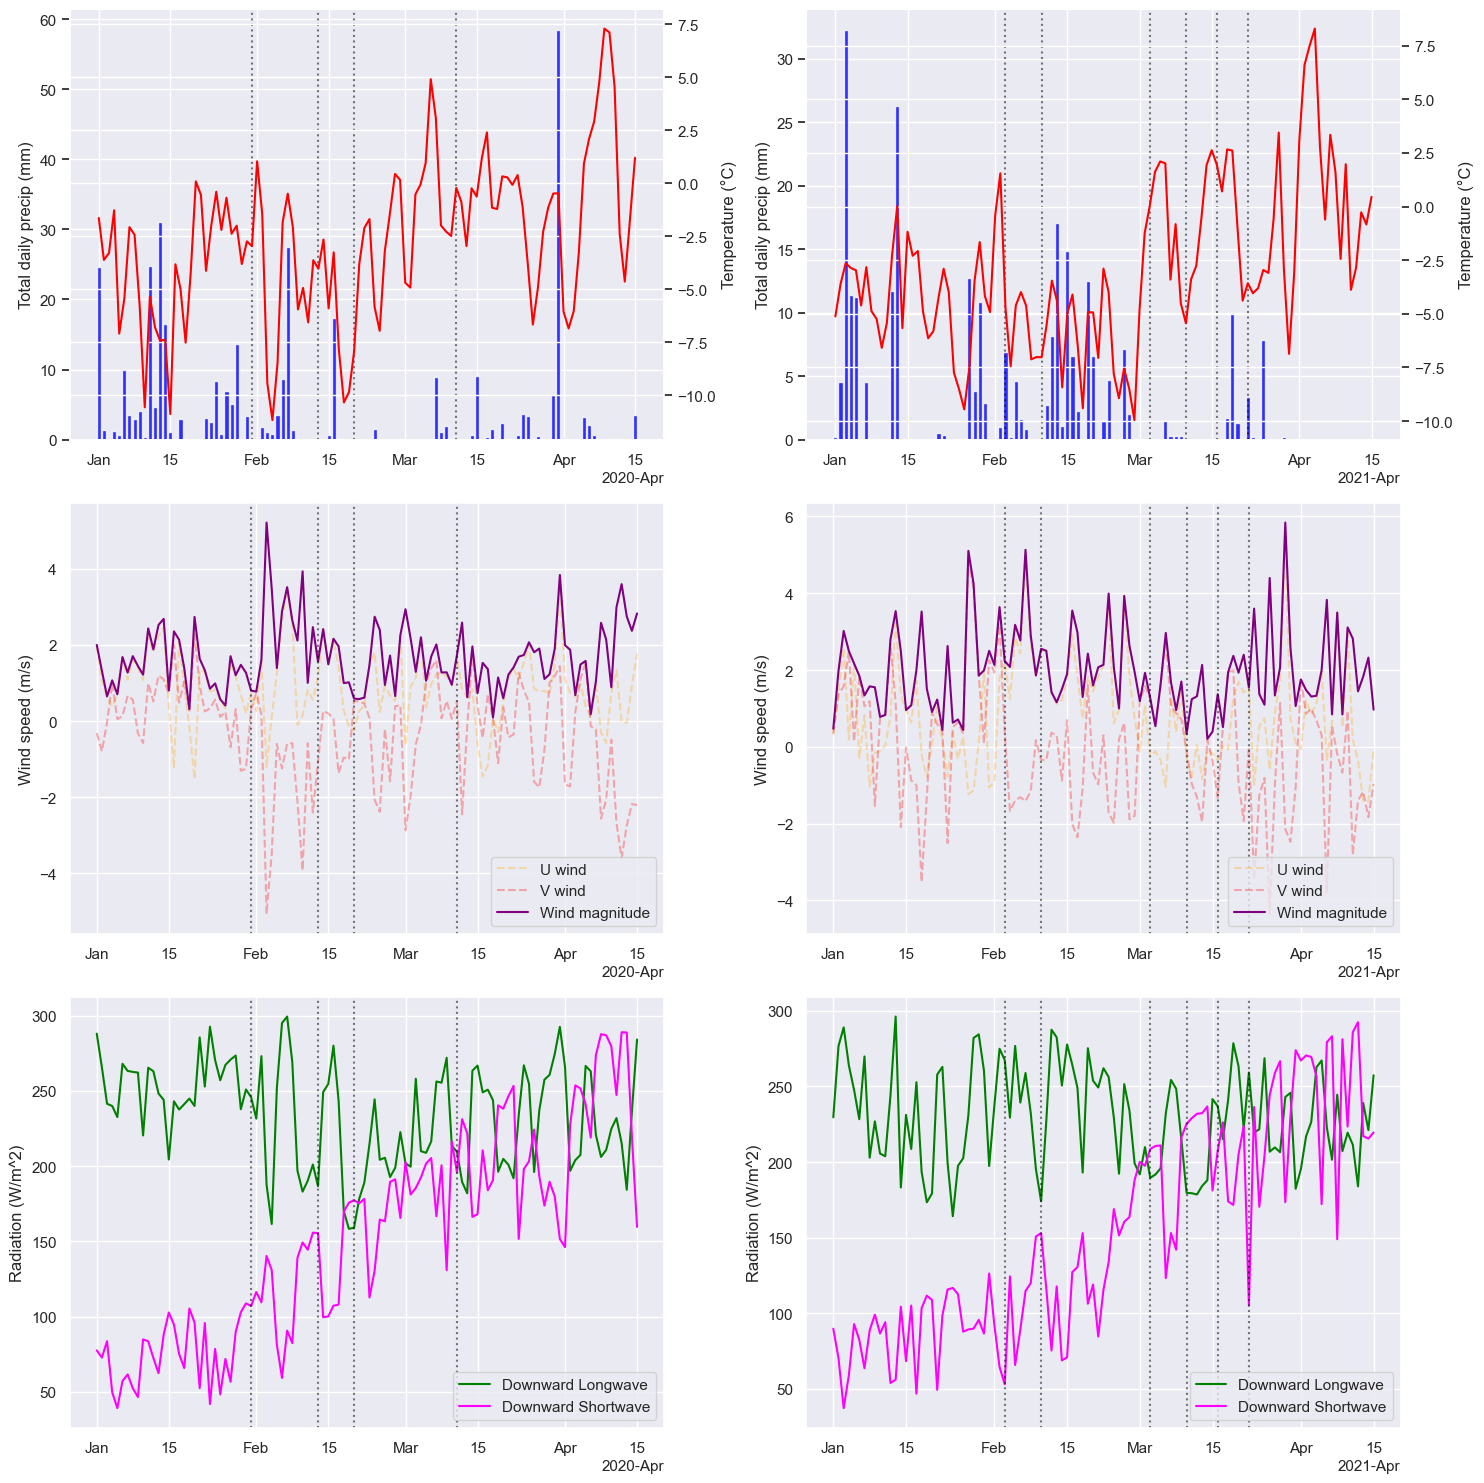

In [ ]:
# plot full time series
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
plot_pairs = [('daily_precip', 'tmp_degC'),
            #   ('tmp_degC', 'SPFH_2maboveground'),
              ('UGRD_10maboveground', 'VGRD_10maboveground'),
              ('DLWRF_surface', 'DSWRF_surface')]

sl2021 = slice(datetime(2021, 1, 1, 0), datetime(2021, 4, 15, 0))
sl2020 = slice(datetime(2020, 1, 1, 0), datetime(2020, 4, 15, 0))
year1 = ds_daily.sel(time=sl2020)
year2 = ds_daily.sel(time=sl2021)
year1dates = [date for date in mcs_dates if date.year == 2020]
year2dates = [date for date in mcs_dates if date.year == 2021]

for i, (var1, var2) in enumerate(plot_pairs):
    if var1 == 'UGRD_10maboveground':
        # do some extra smoothing
        for j, year in enumerate([year1, year2]):
            year[var1].plot(ax=axes[i, j], label='U wind', 
                            linestyle='--', color='orange', alpha=0.3)
            year[var2].plot(ax=axes[i, j], label='V wind', 
                            linestyle='--', color='red', alpha=0.3)
            # ax2 = axes[i].twinx()
            year['wind_mag'].plot(ax=axes[i, j], label='Wind magnitude', 
                                  linestyle='-', color='purple')
            axes[i, j].set_ylabel('Wind speed (m/s)')
            axes[i, j].set_xlabel('')
            axes[i, j].set_title('')
            axes[i, j].legend(loc='lower right')
            # plot vertical line for MCS 
            for date in year1dates if j == 0 else year2dates:
                axes[i, j].axvline(date, color='black', linestyle=':', alpha=0.5)
        # axes[i, j].legend(loc='upper right')
    elif var1 == 'daily_precip':
        for j, year in enumerate([year1, year2]):
            # bar plot 
            axes[i, j].bar(year.time, year[var1], 
                    label='Daily Precip', color='blue', alpha=0.8)
            ax2 = axes[i, j].twinx()
            # year[var1].plot.bar(ax=axes[i, j], label='Daily Precip', color='lightblue')
            year[var2].plot(ax=ax2, label='Temperature (°C)', color='red')
            ax2.set_ylabel('Temperature (°C)')
            ax2.set_title('')
            axes[i, j].set_ylabel('Total daily precip (mm)')
            # rotate x labels
            # plt.setp(axes[i, j].get_xticklabels(), rotation=30)
            axes[i, j].set_xlabel('')
            axes[i, j].set_title('')
            for date in year1dates if j == 0 else year2dates:
                axes[i, j].axvline(date, color='black', linestyle=':', alpha=0.5)
    elif var1 == 'DLWRF_surface':
        for j, year in enumerate([year1, year2]):
            year[var1].plot(ax=axes[i, j], label='Downward Longwave', color='green')
            # ax2=axes[i, j].twinx()
            year[var2].plot(ax=axes[i, j], label='Downward Shortwave', color='magenta')
            axes[i, j].set_ylabel('Radiation (W/m^2)')
            axes[i, j].set_xlabel('')
            axes[i, j].set_title('')
            axes[i, j].legend(loc='lower right')
            # ax2.set_title('')
            for date in year1dates if j == 0 else year2dates:
                axes[i, j].axvline(date, color='black', linestyle=':', alpha=0.5)
    elif var1 == 'tmp_degC':
        for j, year in enumerate([year1, year2]):
            year[var1].plot(ax=axes[i, j], label='Temperature (°C)', color='red')
            # ax2=axes[i, j].twinx()
            # year[var2].plot(ax=ax2, color='orange', alpha=0.5)
            # ax2.spines['right'].set_color('orange')
            # ax2.tick_params(axis='y', colors='orange')
            # ax2.set_title('')
            axes[i, j].set_ylabel('Temperature (°C)')
            axes[i, j].set_xlabel('')
            axes[i, j].set_title('')
            for date in year1dates if j == 0 else year2dates:
                axes[i, j].axvline(date, color='black', linestyle=':', alpha=0.5)

    # axes[i].set_title(f'{vars[0]} and {vars[1]} over time')

plt.tight_layout()
plt.show()